# Siemens Advanta- Bussines Case Project 2025/2026

**Project developed by Group V**:
   - Alano Gonçalves (20250457)
   - Catarina Martins (20221914)
   - João Carichas (20250507)
   - Marta Ribeiro (20221886)
   - Nicole Nogueira(20221961)

## 1. Import the needed libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from math import ceil
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score   
from sklearn.impute import KNNImputer 
import zipfile
import xml.etree.ElementTree as ET

## 2. Data importation

In [3]:
df_merged = pd.read_csv('df_merged.csv')

## 3. Data exploration and understanding

In [4]:
df_merged.tail()

,Period,Biz_Desc,Business_Unit,Segment,Subsegment,Orders,Revenue,China_Core_Inflation_Rate,China_Exports,China_GDP,...,United_States_Exports,United_States_GDP,United_States_GDP_from_Construction,United_States_GDP_from_Manufacturing,United_States_Industrial_Production,United_States_Industrial_Production_Mom,United_States_Inflation_Rate,United_States_Interest_Rate,United_States_Steel_Production,Date
4232,42,SSI,SSI070,SSI07098,SSI07098,0,0,0.1,303.37,18270.36,...,273.687,27720.71,872.5,2389.0,-1.2,-0.6,2.4,5.00,6700.0,2024-09-01
4233,15,SSI,SSI070,SSI07099,SSI07099,15584,15584,1.0,323.41,18201.70,...,262.615,23681.17,851.7,2301.1,3.2,-0.1,9.1,1.75,6900.0,2022-06-01
4234,18,SSI,SSI070,SSI07099,SSI07099,110210,110210,0.6,318.24,18201.70,...,262.473,23681.17,813.5,2302.4,4.6,0.4,8.2,3.25,6600.0,2022-09-01
4235,21,SSI,SSI070,SSI07099,SSI07099,273671,273671,0.7,296.90,18316.77,...,253.508,26006.89,806.3,2274.6,-0.8,-1.2,6.5,4.50,6500.0,2022-12-01
4236,24,SSI,SSI070,SSI07099,SSI07099,472923,472923,0.7,302.45,18316.77,...,259.541,26006.89,810.8,2224.4,-0.4,0.4,5.0,5.00,6700.0,2023-03-01


In [5]:
#overview the dataset
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4237 entries, 0 to 4236
Data columns (total 82 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Period                                    4237 non-null   int64  
 1   Biz_Desc                                  4237 non-null   object 
 2   Business_Unit                             4237 non-null   object 
 3   Segment                                   4237 non-null   object 
 4   Subsegment                                4237 non-null   object 
 5   Orders                                    4237 non-null   int64  
 6   Revenue                                   4237 non-null   int64  
 7   China_Core_Inflation_Rate                 4237 non-null   float64
 8   China_Exports                             4237 non-null   float64
 9   China_GDP                                 4237 non-null   float64
 10  China_GDP_from_Construction         

In [6]:
# get all combinations of subsegments and periods that should exist
all_periods     = pd.DataFrame({'Period': range(1, 43)})
all_subsegments = df_merged[['Business_Unit', 'Segment', 'Subsegment']].drop_duplicates()

# cross join to get every possible combination
full_grid = all_subsegments.assign(key=1).merge(all_periods.assign(key=1), on='key').drop('key', axis=1)

# merge with actual data to find missing combinations
df_merged = full_grid.merge(df_merged, on=['Period', 'Business_Unit', 'Segment', 'Subsegment'], how='left')

# fill revenue and orders with 0 where missing
df_merged['Revenue'] = df_merged['Revenue'].fillna(0)
df_merged['Orders']  = df_merged['Orders'].fillna(0)

# track start period per subsegment (first period where it actually appeared in original data)
start_periods = (
    df_merged[df_merged['Revenue'] != 0]
    .groupby('Subsegment')['Period']
    .min()
    .reset_index()
    .rename(columns={'Period': 'Start_Period'})
)
df_merged = df_merged.merge(start_periods, on='Subsegment', how='left')

print(df_merged.shape)
print(df_merged[['Period', 'Subsegment', 'Revenue', 'Start_Period']].head(20))

(5628, 83)
    Period Subsegment    Revenue  Start_Period
0        1   SSI02710  -390277.0           1.0
1        2   SSI02710      334.0           1.0
2        3   SSI02710      334.0           1.0
3        4   SSI02710  1811758.0           1.0
4        5   SSI02710    80112.0           1.0
5        6   SSI02710    38468.0           1.0
6        7   SSI02710      334.0           1.0
7        8   SSI02710      334.0           1.0
8        9   SSI02710   -37173.0           1.0
9       10   SSI02710    38094.0           1.0
10      11   SSI02710      334.0           1.0
11      12   SSI02710      334.0           1.0
12      13   SSI02710      334.0           1.0
13      14   SSI02710      334.0           1.0
14      15   SSI02710      334.0           1.0
15      16   SSI02710      334.0           1.0
16      17   SSI02710      334.0           1.0
17      18   SSI02710      334.0           1.0
18      19   SSI02710      334.0           1.0
19      20   SSI02710      334.0           1.0


In [7]:
# count how many distinct subsegments each segment has
subseg_counts = (
    df_merged.groupby('Segment')['Subsegment']
    .nunique()
    .reset_index()
    .rename(columns={'Subsegment': 'Subseg_Count'})
)

df_merged = df_merged.merge(subseg_counts, on='Segment', how='left')

# only flag as direct if segment = subsegment AND it's the only subsegment
df_merged['Is_Direct'] = (
    (df_merged['Segment'] == df_merged['Subsegment']) &
    (df_merged['Subseg_Count'] == 1)
)

print("Direct cases (segment = subsegment, no other subsegments):")
print(df_merged[df_merged['Is_Direct']]['Segment'].unique())
print("Count of direct segments:", df_merged[df_merged['Is_Direct']]['Segment'].nunique())

Direct cases (segment = subsegment, no other subsegments):
['SSI02792' 'SSI02793' 'SSI02796' 'SSI02798' 'SSI02799' 'SSI03784'
 'SSI03798' 'SSI03799' 'SSI04799' 'SSI07098' 'SSI07099']
Count of direct segments: 11


### 3.2. EDA and feature visualization

**REVENUE OVER TIME PER SEGMENT**

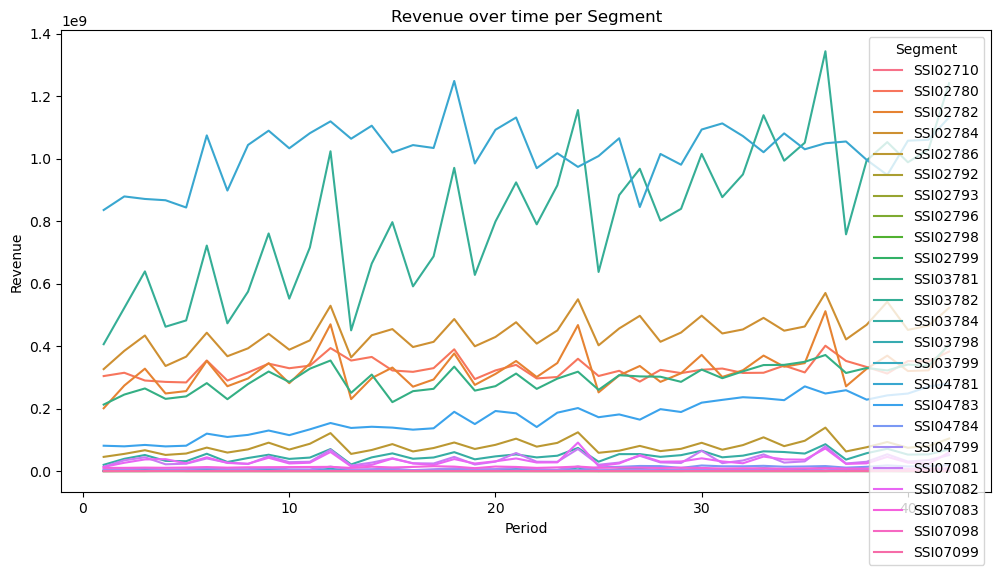

In [13]:
# aggregate revenue per segment per period
df_seg = df_merged.groupby(['Period', 'Segment'])['Revenue'].sum().reset_index()

plt.figure(figsize=(12,6))
sns.lineplot(data=df_seg, x='Period', y='Revenue', hue='Segment')
plt.title("Revenue over time per Segment")
plt.show()

**SEASONALITY CHECK**

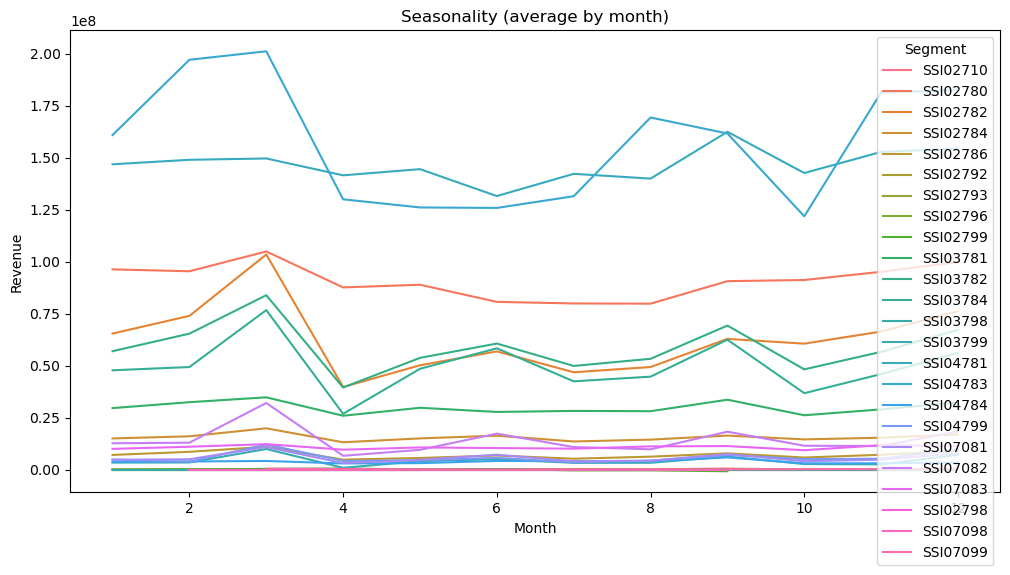

In [14]:
# extract month if you have actual date
df_merged['Month'] = pd.to_datetime(df_merged['Date']).dt.month

seasonality = (
    df_merged.groupby(['Month', 'Segment'])['Revenue']
    .mean()
    .reset_index()
)

plt.figure(figsize=(12,6))
sns.lineplot(data=seasonality, x='Month', y='Revenue', hue='Segment')
plt.title("Seasonality (average by month)")
plt.show()

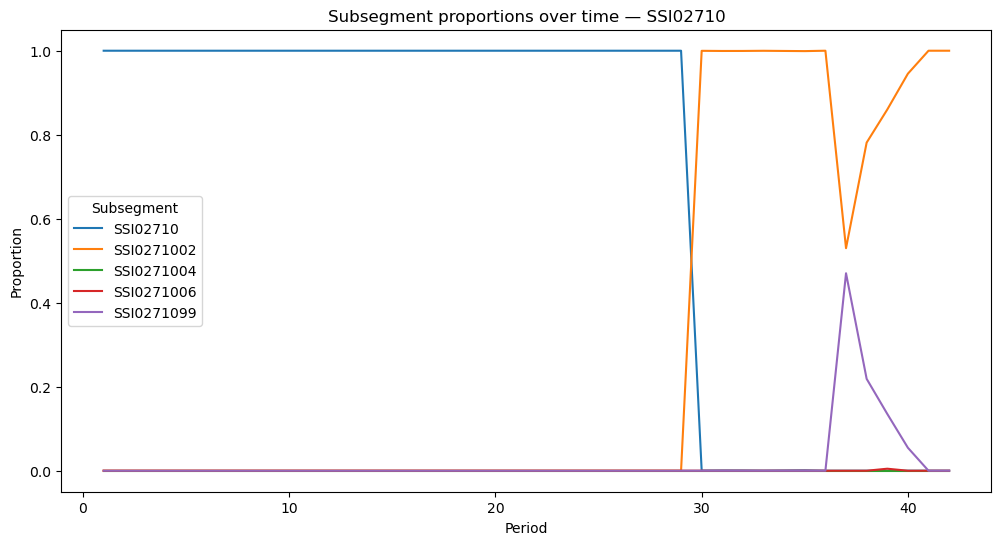

In [15]:
# compute proportions
df_prop = (
    df_merged.groupby(['Period', 'Segment', 'Subsegment'])['Revenue']
    .sum()
    .reset_index()
)

# total per segment
df_total = (
    df_prop.groupby(['Period', 'Segment'])['Revenue']
    .sum()
    .reset_index()
    .rename(columns={'Revenue': 'Segment_Revenue'})
)

df_prop = df_prop.merge(df_total, on=['Period', 'Segment'])
df_prop['Proportion'] = df_prop['Revenue'] / df_prop['Segment_Revenue']

# plot for a sample segment
sample_segment = df_prop['Segment'].unique()[0]

df_sample = df_prop[df_prop['Segment'] == sample_segment]

plt.figure(figsize=(12,6))
sns.lineplot(data=df_sample, x='Period', y='Proportion', hue='Subsegment')
plt.title(f"Subsegment proportions over time — {sample_segment}")
plt.show()

### 3.3. Checking Duplicates

In [92]:
#checking number of duplicates
train_data.duplicated().sum()

np.int64(0)

In [93]:
#checking number of duplicates
df_market.duplicated().sum()

np.int64(0)

- None of the datasets present duplicates.

### 3.4. Checking Missing Values

In [94]:
#checking number of missing values
train_data.isna().sum()

Period           0
Biz_Desc         0
Business_Unit    0
Segment          0
Subsegment       0
Orders           0
Revenue          0
dtype: int64

- The train dataset does not present any missing values which is a good sign.

In [95]:
#checking number of missing values
df_market.isna().sum()

Period                                        0
China_Core_Inflation_Rate                     2
China_Exports                                 2
China_GDP                                   165
China_GDP_from_Construction                 120
China_GDP_from_Manufacturing                120
China_Industrial_Production                   4
China_Industrial_Production_Mom              10
China_Inflation_Rate                          2
China_Interest_Rate                          43
China_Steel_Production                        0
France_Core_Inflation_Rate                    2
France_Exports                                2
France_GDP                                  165
France_GDP_from_Construction                120
France_GDP_from_Manufacturing               120
France_Industrial_Production                  2
France_Industrial_Production_Mom              2
France_Inflation_Rate                         2
France_Interest_Rate                          4
France_Steel_Production                 

In [96]:
pd.set_option('display.max_rows', None)
df_market.isna().sum()/len(df_market) * 100

Period                                       0.000000
China_Core_Inflation_Rate                    1.111111
China_Exports                                1.111111
China_GDP                                   91.666667
China_GDP_from_Construction                 66.666667
China_GDP_from_Manufacturing                66.666667
China_Industrial_Production                  2.222222
China_Industrial_Production_Mom              5.555556
China_Inflation_Rate                         1.111111
China_Interest_Rate                         23.888889
China_Steel_Production                       0.000000
France_Core_Inflation_Rate                   1.111111
France_Exports                               1.111111
France_GDP                                  91.666667
France_GDP_from_Construction                66.666667
France_GDP_from_Manufacturing               66.666667
France_Industrial_Production                 1.111111
France_Industrial_Production_Mom             1.111111
France_Inflation_Rate       

- The variables whose missing values represent more than 50% of the data correspond to columns that have informatio about the GDP
Some columns present a high amount of missing values- almost 92% of the total data. In those cases, the information given is not sufficiently significant to consider these variables.
- 

- Data that have more than 50% of missing observations correspond to the GDP columns of each country (for example, China_GDP, China_GDP_from_Construction, China_GDP_from_Manufacturing, etc). In these cases, it is normal for the GDP to have a high quantity of missing values considering that the GDP of each country can only be calculated at the end of each year and since we have our data per month, this is the usual behavior. 
- The rest of the columns have less than 50% of missing values (usually the values do not exceed 5%, except for steel production).For the columns corresponding to steel production, there are some countries that for the possitive months (the ones we are going to consider later on merge) have 100% of missing values. 

In [97]:
#creating a variable that has df_market data from the 1 to 42 months 
df_market_months = df_market[df_market['Period'].between(1, 42)]

In [98]:
pd.set_option('display.max_rows', None)
df_market_months.isna().sum()/len(df_market_months) * 100

Period                                        0.000000
China_Core_Inflation_Rate                     0.000000
China_Exports                                 0.000000
China_GDP                                    92.857143
China_GDP_from_Construction                  66.666667
China_GDP_from_Manufacturing                 66.666667
China_Industrial_Production                   2.380952
China_Industrial_Production_Mom               0.000000
China_Inflation_Rate                          0.000000
China_Interest_Rate                           0.000000
China_Steel_Production                        0.000000
France_Core_Inflation_Rate                    0.000000
France_Exports                                0.000000
France_GDP                                   92.857143
France_GDP_from_Construction                 66.666667
France_GDP_from_Manufacturing                66.666667
France_Industrial_Production                  0.000000
France_Industrial_Production_Mom              0.000000
France_Inf

- If we consider only the observations whose period we are going to consider when merging with *train_data*, some of these observations have 100% missing values. In those cases, it is useless to consider them. 
- All variables that have missing values, also have a high percentage (>60%), except for *United_States_Interest_Rate* that has only 2.3% and *China_Industrial_Production* that has 2.3%. Therefore, these are the only variables worth of handling missing values.

### 3.5. Checking Outliers

In [99]:
#setting metric fearures for train_data
metric_features_train= ['Revenue', 'Orders']

In [100]:
#setting metric fearures for df_market
metric_features_market= ['China_Core_Inflation_Rate', 'China_Exports', 'China_GDP', 
                         'China_Industrial_Production', 'China_Industrial_Production_Mom', 
                         'China_Inflation_Rate', 'China_Interest_Rate', 'China_Steel_Production', 
                         'France_Core_Inflation_Rate', 'France_Exports', 'France_Industrial_Production',
                         'France_Industrial_Production_Mom', 'France_Inflation_Rate', 'France_Interest_Rate', 
                         'Germany_Core_Inflation_Rate', 'Germany_Exports', 'Germany_Industrial_Production', 
                         'Germany_Industrial_Production_Mom', 'Germany_Inflation_Rate', 'Germany_Interest_Rate', 
                         'Germany_Steel_Production', 'Italy_Core_Inflation_Rate', 'Italy_Exports', 'Italy_Industrial_Production',
                         'Italy_Industrial_Production_Mom', 'Italy_Inflation_Rate', 'Italy_Interest_Rate', 'Japan_Core_Inflation_Rate',
                         'Japan_Exports', 'Japan_Industrial_Production', 'Japan_Industrial_Production_Mom', 'Japan_Inflation_Rate', 
                         'Japan_Interest_Rate', 'Japan_Steel_Production', 'Switzerland_Core_Inflation_Rate', 'Switzerland_Exports', 
                         'Switzerland_Inflation_Rate', 'Switzerland_Interest_Rate', 'United_Kingdom_Core_Inflation_Rate', 'United_Kingdom_Exports', 
                         'United_Kingdom_Industrial_Production', 'United_Kingdom_Industrial_Production_Mom', 'United_Kingdom_Inflation_Rate', 
                         'United_Kingdom_Interest_Rate', 'United_States_Core_Inflation_Rate', 'United_States_Exports', 
                         'United_States_Industrial_Production', 'United_States_Industrial_Production_Mom', 'United_States_Inflation_Rate', 
                         'United_States_Steel_Production'
]

In [101]:
def plot_multiple_boxplots(data, feats, n_cols=2, title="Numeric Variables - Box Plots"):

    #defining grid size
    n_rows = ceil(len(feats) / n_cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(6 * n_cols, 4.5 * n_rows)
    )

    axes = axes.flatten()
    #looping through features
    for i, feat in enumerate(feats):

        #keeping ALL values except missing ones
        values = data[feat].dropna()

        #plotting only if there is data
        if len(values) > 0:
            sns.boxplot(x=values, ax=axes[i], color="#798a40")
            axes[i].set_title(feat, fontsize=10)
        else:
            axes[i].set_title(f"{feat} (no data)", fontsize=10)

    # removing empty subplots
    for j in range(len(feats), len(axes)):
        fig.delaxes(axes[j])

    # final layout adjustments
    plt.suptitle(title, fontsize=18)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

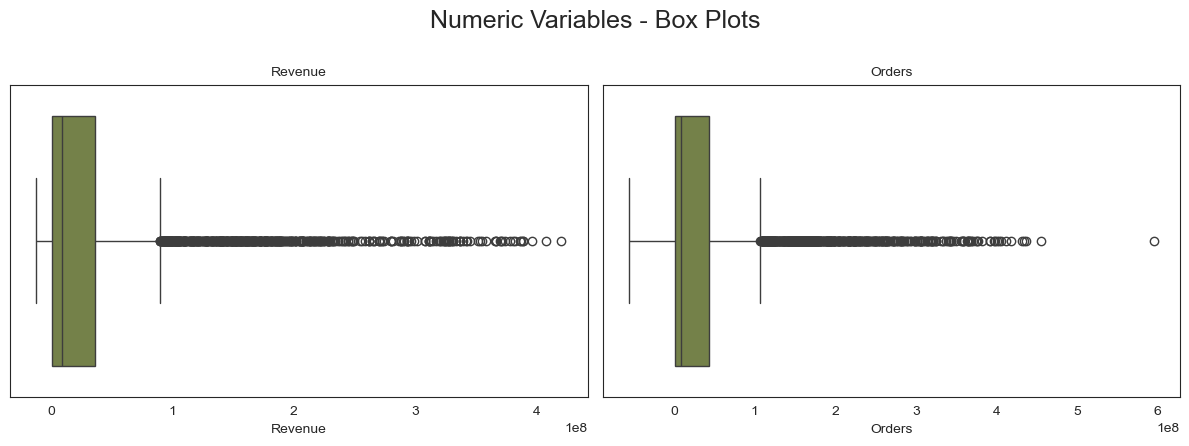

In [102]:
#applying the function to our numerical features
plot_multiple_boxplots(train_data, metric_features_train)

In [103]:
def plot_multiple_boxplots(data, feats, n_cols=3, title="Numeric Variables - Box Plots"):

    #defining grid size
    n_rows = ceil(len(feats) / n_cols)

    fig, axes = plt.subplots(
        n_rows,
        n_cols,
        figsize=(6 * n_cols, 4.5 * n_rows)
    )

    axes = axes.flatten()
    #looping through features
    for i, feat in enumerate(feats):

        #keeping ALL values except missing ones
        values = data[feat].dropna()

        #plotting only if there is data
        if len(values) > 0:
            sns.boxplot(x=values, ax=axes[i], color="#798a40")
            axes[i].set_title(feat, fontsize=10)
        else:
            axes[i].set_title(f"{feat} (no data)", fontsize=10)

    # removing empty subplots
    for j in range(len(feats), len(axes)):
        fig.delaxes(axes[j])

    # final layout adjustments
    plt.suptitle(title, fontsize=18)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

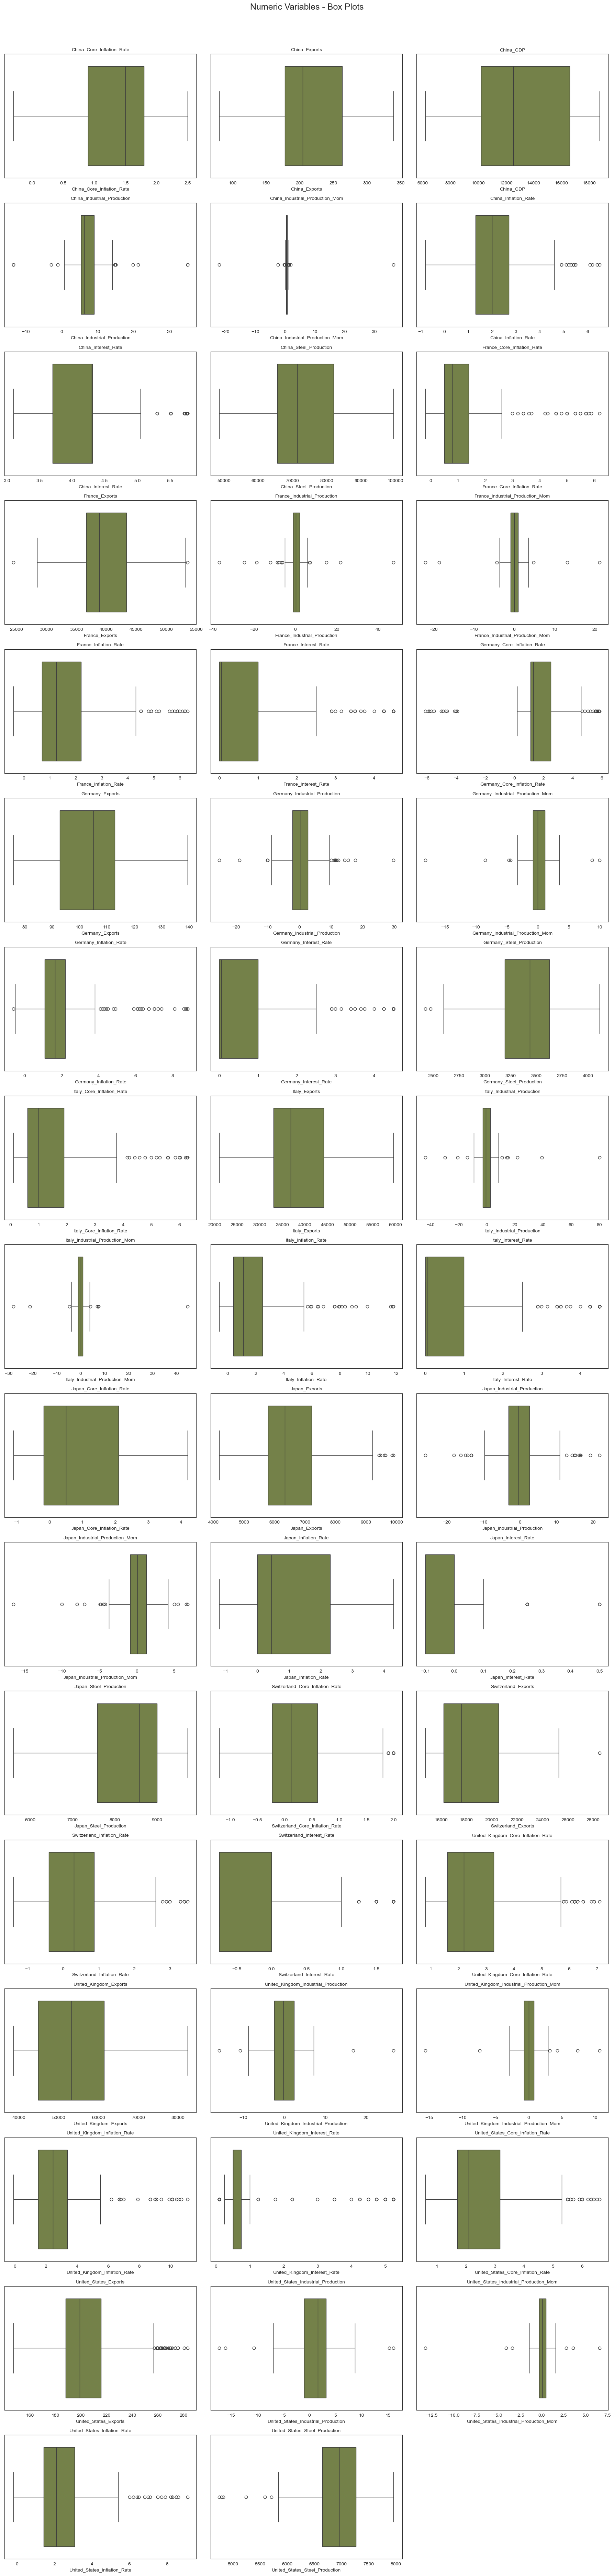

In [104]:
#applying the function to our numerical features
plot_multiple_boxplots(df_market, metric_features_market)

- Even tough there are some outliers, these values correspond to real macroeconomic indicators (like inflation, post-COVID period, etc.). If we applied some capping or transformation to try handle them, we would be distorting the actual economic reality that your model needs to learn from. Therefore, we have decided to keep the data as it is for now. 

### 3.6. Checking Distribution

In [105]:
df= pd.DataFrame(train_data[metric_features_train])

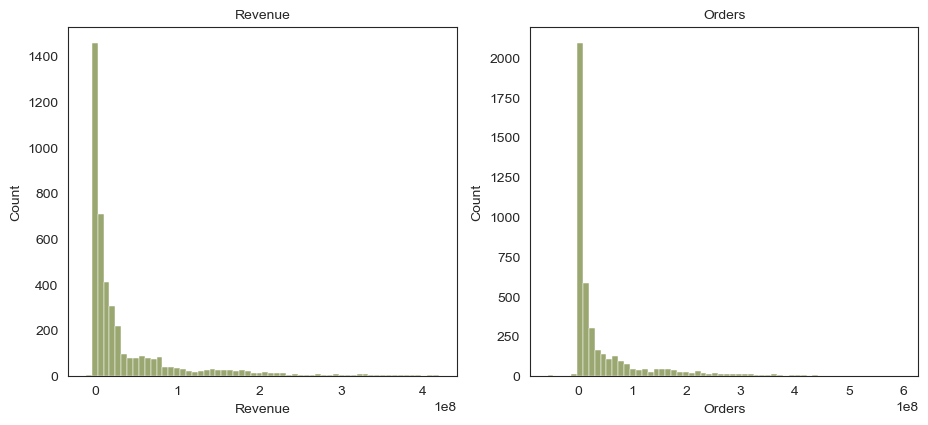

In [106]:
#setting visual style
sns.set_style("white")  # clean background for reports
#sampling the dataset
N = 200_000
sample = train_data.sample(n=min(N, len(train_data)), random_state=42)

#selecting numeric variables
cols = metric_features_train

#defining plotting structure
plots_per_fig = 6   
n_figs = ceil(len(cols) / plots_per_fig)

#looping through figures
for f in range(n_figs):
    
    #selecting subset of columns for current figure
    start = f * plots_per_fig
    end = start + plots_per_fig
    subset_cols = cols[start:end]
    
    #creating subplot grid
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.ravel()
    
    #ploting histograms
    for ax, col in zip(axes, subset_cols):
        
        #removing missing values only 
        data = sample[col].dropna()
        
        sns.histplot(
            data,
            bins=60,
            kde=False,
            ax=ax,
            color="#798a40"   
        )
        
        ax.set_title(col, fontsize=10)

    #removing empty subplots
    for j in range(len(subset_cols), len(axes)):
        fig.delaxes(axes[j])
    
        #adjusting layout and display
    plt.tight_layout()
    plt.show()

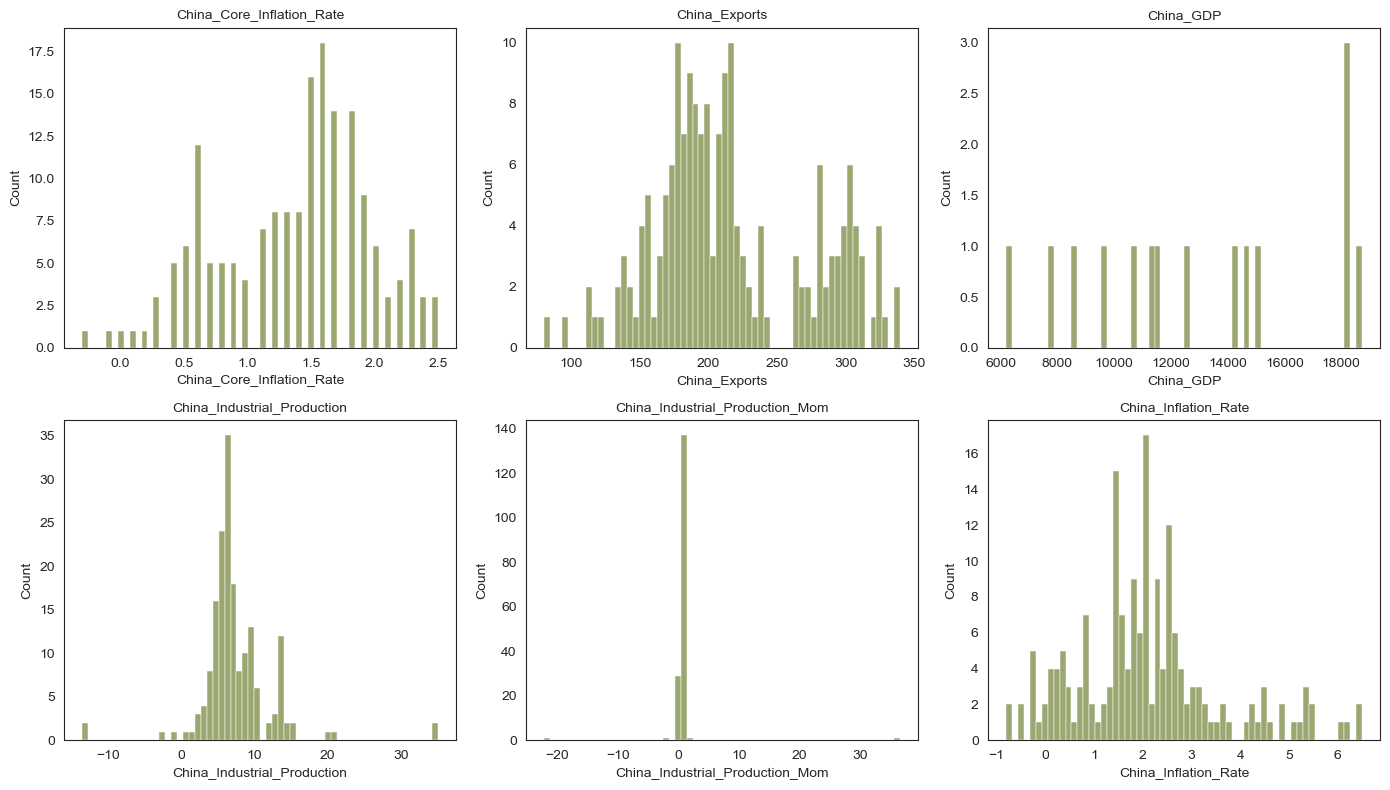

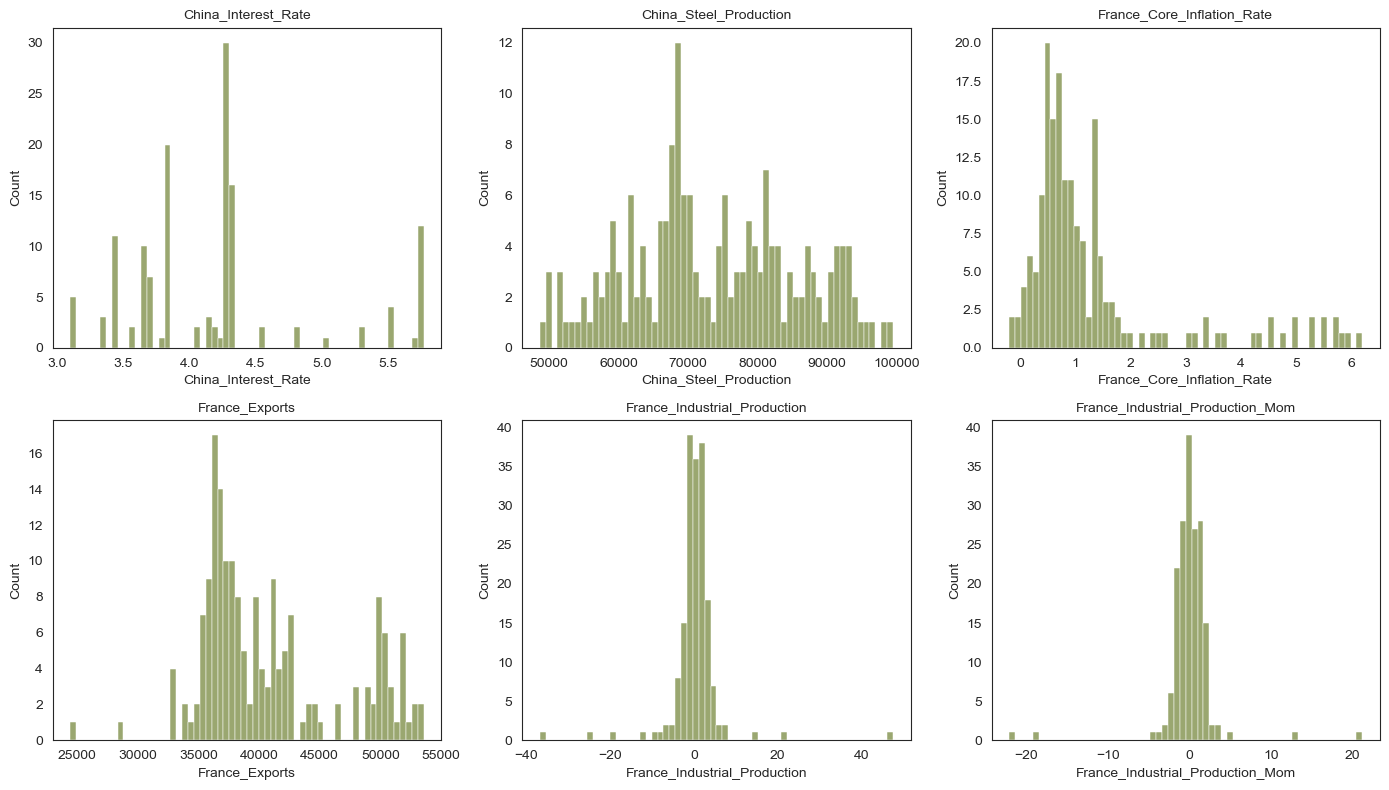

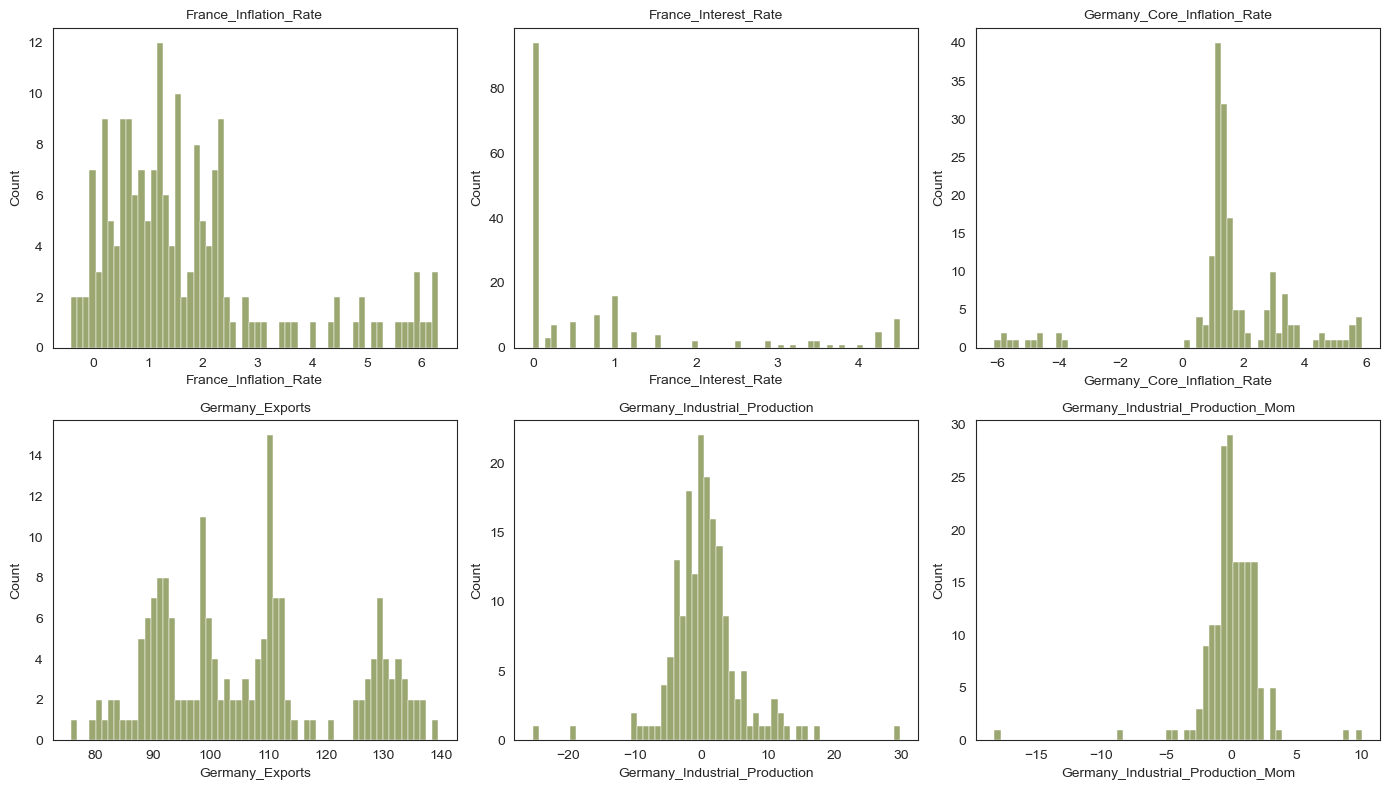

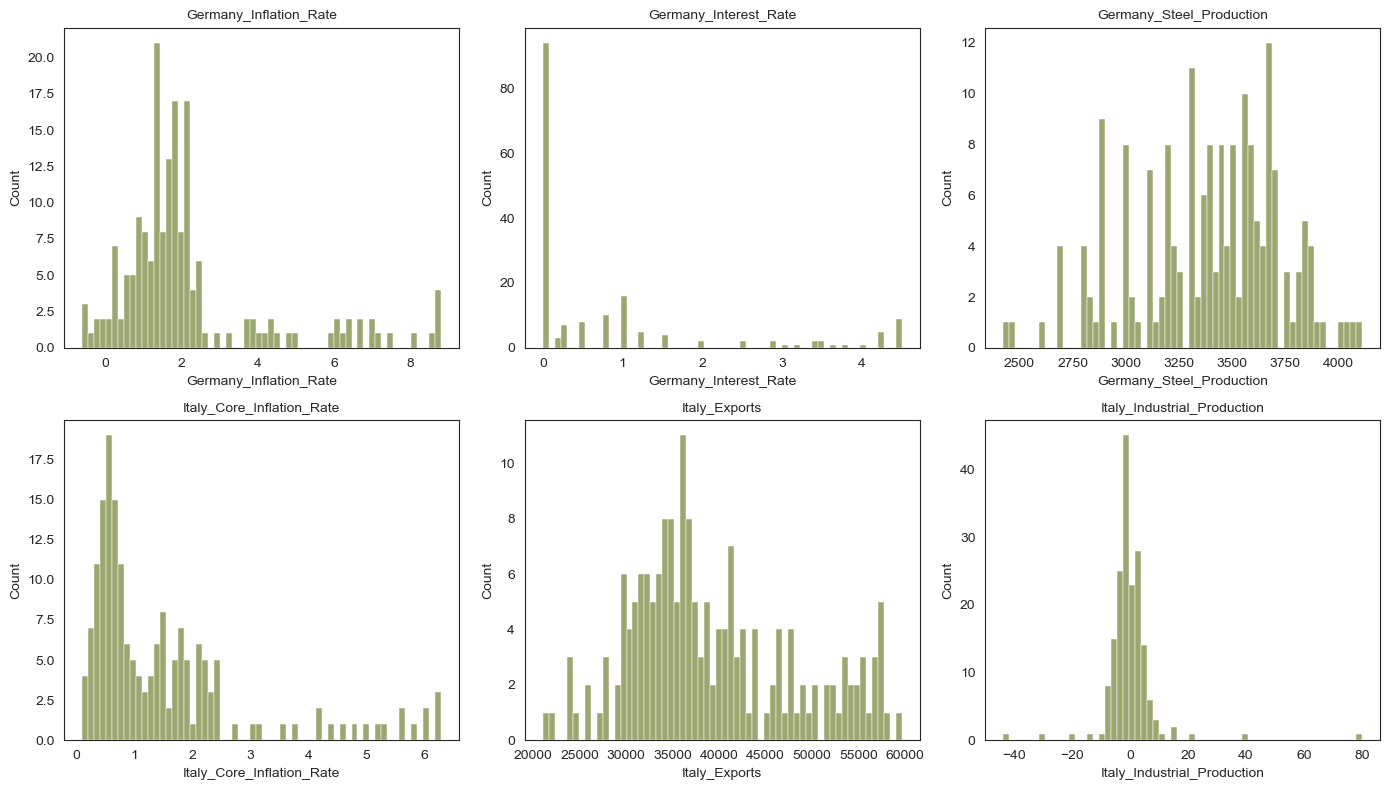

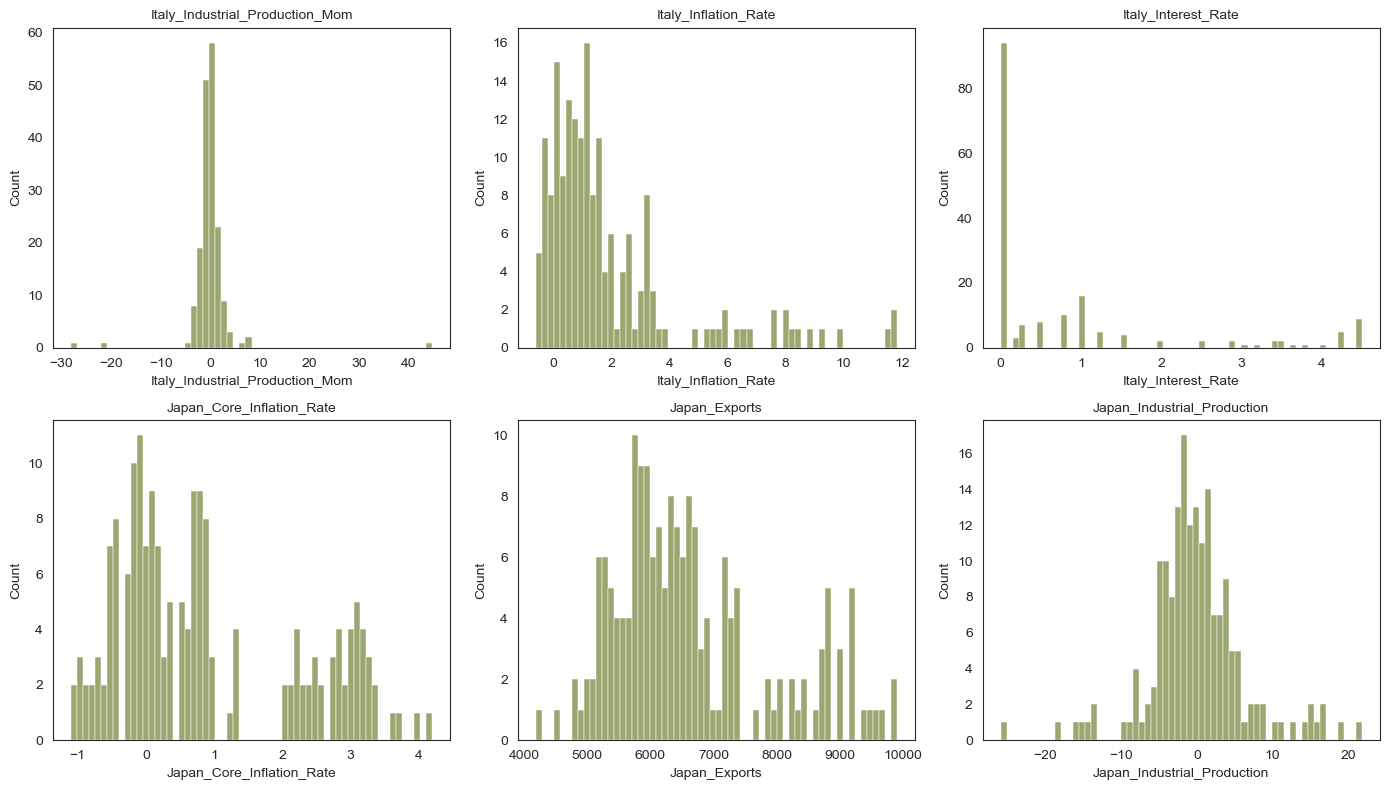

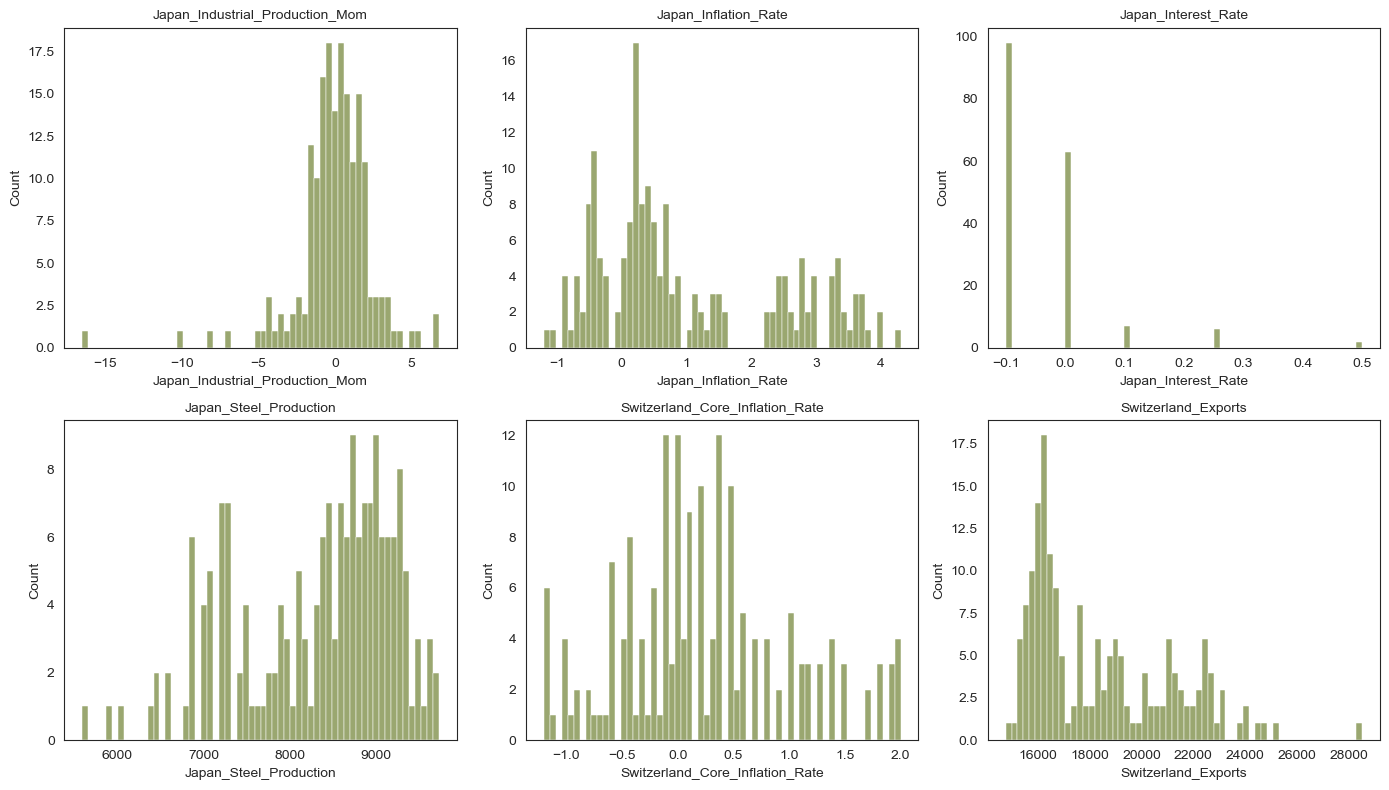

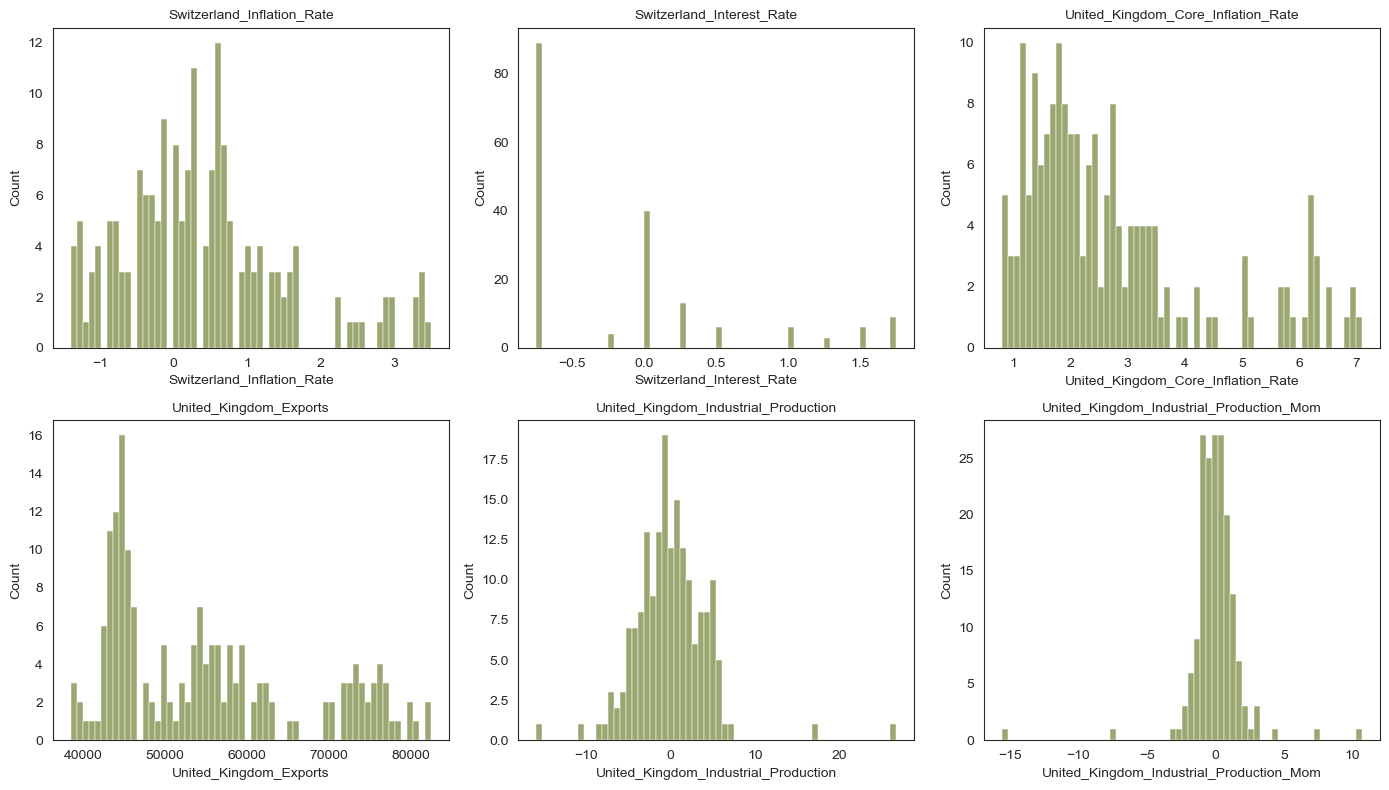

KeyboardInterrupt: 

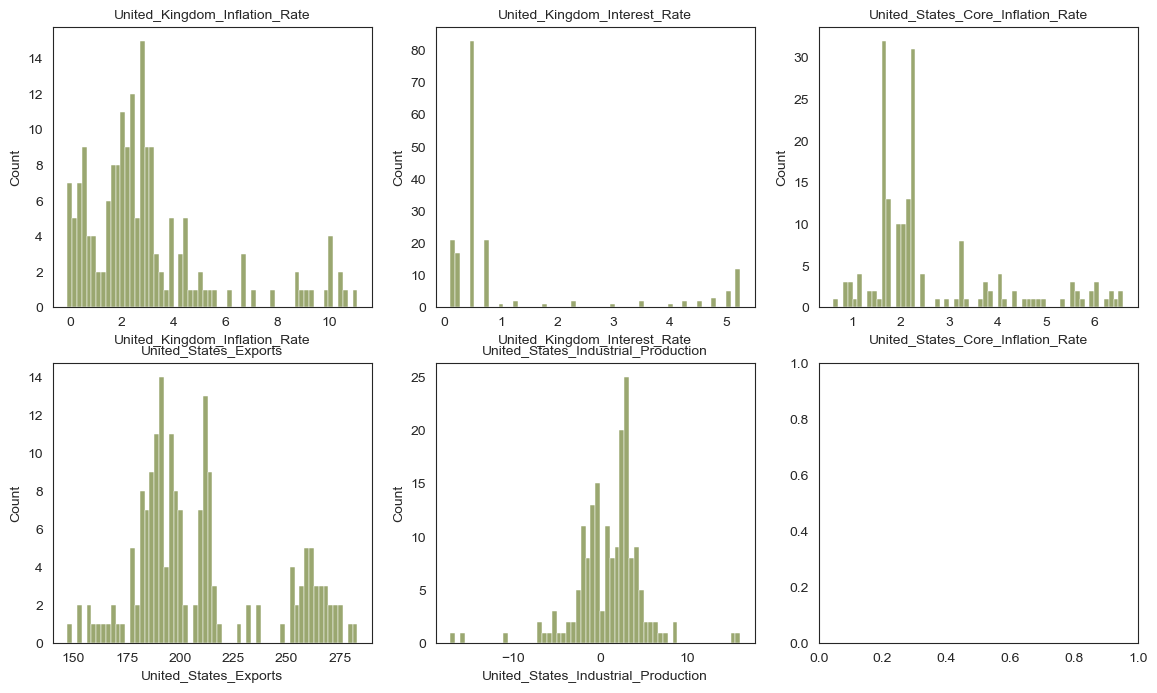

In [107]:
#setting visual style
sns.set_style("white")  # clean background for reports
#sampling the dataset
N = 200_000
sample = df_market.sample(n=min(N, len(df_market)), random_state=42)

#selecting numeric variables
cols = metric_features_market

#defining plotting structure
plots_per_fig = 6   
n_figs = ceil(len(cols) / plots_per_fig)

#looping through figures
for f in range(n_figs):
    
    #selecting subset of columns for current figure
    start = f * plots_per_fig
    end = start + plots_per_fig
    subset_cols = cols[start:end]
    
    #creating subplot grid
    fig, axes = plt.subplots(2, 3, figsize=(14, 8))
    axes = axes.ravel()
    
    #ploting histograms
    for ax, col in zip(axes, subset_cols):
        
        #removing missing values only 
        data = sample[col].dropna()
        
        sns.histplot(
            data,
            bins=60,
            kde=False,
            ax=ax,
            color="#798a40"   
        )
        
        ax.set_title(col, fontsize=10)

    #removing empty subplots
    for j in range(len(subset_cols), len(axes)):
        fig.delaxes(axes[j])
    
        #adjusting layout and display
    plt.tight_layout()
    plt.show()

### 3.7. Checking Correlation between variables

In [ ]:
#checking correlation between variables 
#we are going to use spearman correlation since our variables do not follow a normal distribution
cor_spearman = df_market[metric_features_market].corr(method ='spearman')
cor_spearman

,China_Core_Inflation_Rate,China_Exports,China_GDP,China_Industrial_Production,China_Industrial_Production_Mom,China_Inflation_Rate,China_Interest_Rate,China_Steel_Production,France_Core_Inflation_Rate,France_Exports,...,United_Kingdom_Industrial_Production,United_Kingdom_Industrial_Production_Mom,United_Kingdom_Inflation_Rate,United_Kingdom_Interest_Rate,United_States_Core_Inflation_Rate,United_States_Exports,United_States_Industrial_Production,United_States_Industrial_Production_Mom,United_States_Inflation_Rate,United_States_Steel_Production
China_Core_Inflation_Rate,1.000000,-0.601535,-0.641005,0.350778,0.110067,0.489509,0.763456,-0.519185,-0.470539,-0.445736,...,0.129136,0.063294,-0.045124,-0.278393,-0.419716,-0.410172,0.244042,0.004236,-0.203296,0.346979
China_Exports,-0.601535,1.000000,0.932143,-0.534005,-0.253287,-0.556201,-0.716840,0.765034,0.413557,0.755412,...,-0.067462,-0.037299,0.165909,0.332794,0.594231,0.779905,-0.144228,-0.012998,0.491679,-0.088536
China_GDP,-0.641005,0.932143,1.000000,-0.705988,-0.536429,-0.694721,-0.943685,0.807143,0.481217,0.942857,...,-0.058981,-0.201966,0.175000,0.403616,0.703146,0.910714,-0.480787,-0.304388,0.550985,-0.175000
China_Industrial_Production,0.350778,-0.534005,-0.705988,1.000000,0.483968,0.298135,0.475174,-0.574685,-0.303811,-0.630758,...,0.088079,-0.068754,0.003491,-0.349172,-0.597015,-0.527057,0.388441,0.171938,-0.232295,0.212601
China_Industrial_Production_Mom,0.110067,-0.253287,-0.536429,0.483968,1.000000,0.304943,0.031023,-0.199254,-0.143508,-0.453833,...,-0.057605,-0.015859,-0.015704,-0.163640,-0.408471,-0.410135,-0.062856,0.074491,-0.183883,-0.031805
China_Inflation_Rate,0.489509,-0.556201,-0.694721,0.298135,0.304943,1.000000,0.473119,-0.457820,-0.131786,-0.592795,...,-0.106269,0.034190,0.105715,-0.117586,-0.334955,-0.541774,0.289531,0.082164,-0.142046,0.358545
China_Interest_Rate,0.763456,-0.716840,-0.943685,0.475174,0.031023,0.473119,1.000000,-0.594454,-0.732886,-0.712972,...,0.504204,0.089586,-0.518614,-0.386924,-0.649751,-0.619018,0.170641,-0.071090,-0.632366,0.397936
China_Steel_Production,-0.519185,0.765034,0.807143,-0.574685,-0.199254,-0.457820,-0.594454,1.000000,0.242274,0.664963,...,0.081263,0.012418,-0.018187,0.186418,0.454955,0.655751,-0.306479,0.051236,0.344398,-0.123561
France_Core_Inflation_Rate,-0.470539,0.413557,0.481217,-0.303811,-0.143508,-0.131786,-0.732886,0.242274,1.000000,0.558090,...,-0.434278,-0.130584,0.638881,0.565150,0.710207,0.464588,0.095544,-0.001930,0.687309,-0.015814
France_Exports,-0.445736,0.755412,0.942857,-0.630758,-0.453833,-0.592795,-0.712972,0.664963,0.558090,1.000000,...,-0.053031,-0.020413,0.274422,0.566934,0.774614,0.892917,-0.164116,-0.113626,0.580744,-0.117215


In [ ]:
#creating correlation matrix to facilitate interpretation
def cor_heatmap(cor):
    
    #setting the figure size
    plt.figure(figsize=(12, 10))

    #creating a mask for the upper triangle of the matrix (to avoid plotting duplicate correlation values)
    mask = np.triu(np.ones_like(cor, dtype=bool))

    #plotting the correlation heatmap
    sns.heatmap(
        data=cor,                 #correlation matrix input
        mask=mask,                #applying upper-triangle mask
        annot=True,               #displaying correlation coefficients
        cmap=sns.light_palette("#798a40", as_cmap=True), #color map for visual contrast
        fmt='.2f',                #formatting values to two decimals
        square=True,              #ensuring square-shaped cells
        linewidths=0.5,           #adding grid lines between cells
        cbar_kws={"shrink": 0.8}  #adjusting color bar size
    )

    #adding a title and display the plot
    plt.title("Spearman Correlation Matrix", fontsize=14)
    plt.show()

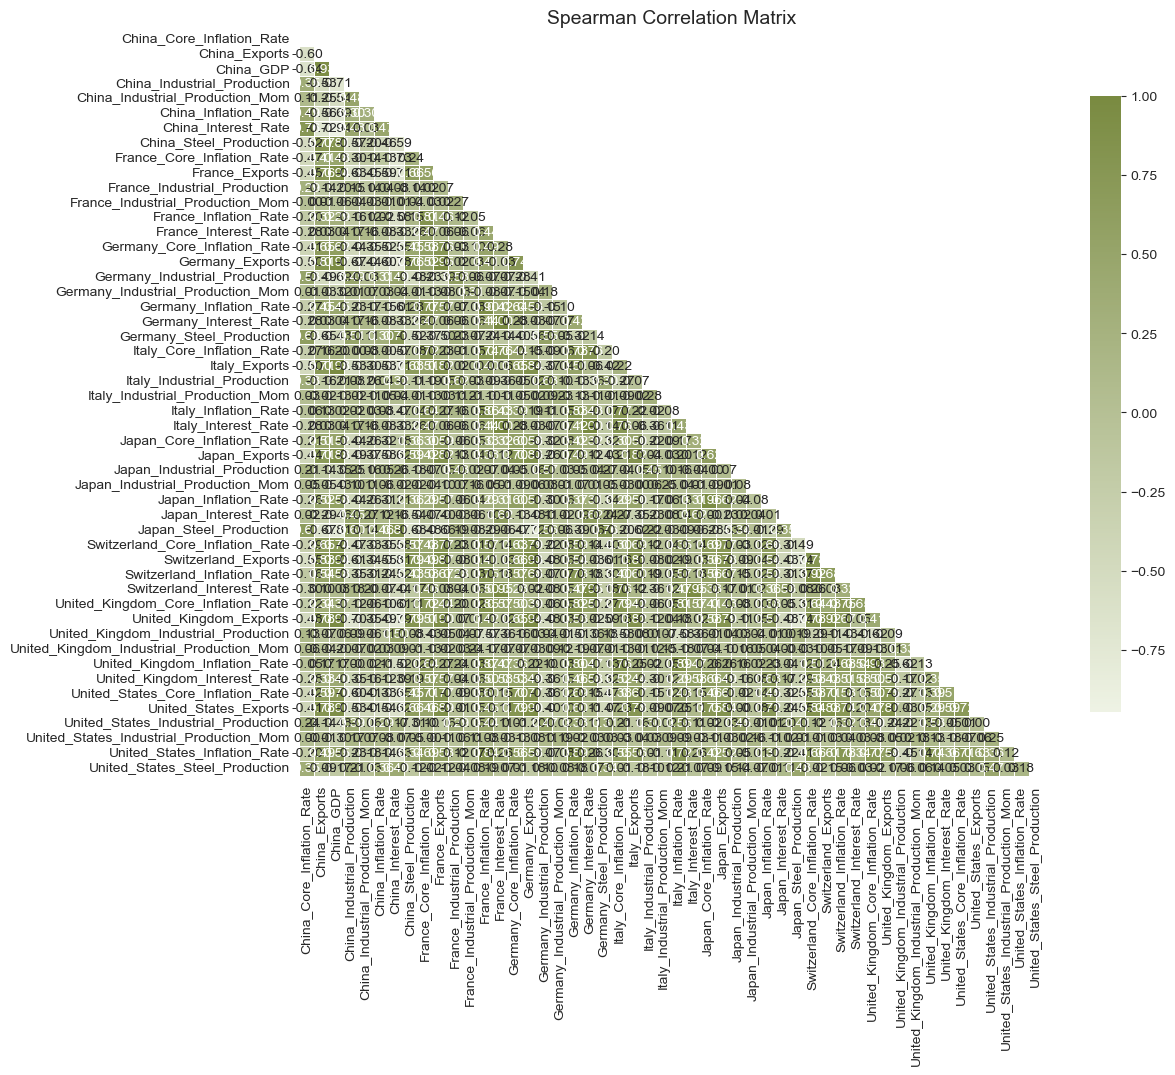

In [ ]:
#applying the function to our numerical features
cor_heatmap(cor_spearman)

## 4. Data Preparation

### 4.1. Handling Missing Values

- For columns with >50% missing values (corresponding to GDP columns), we have decided to fill the missing observations with the value of the GDP of that year. 
- For columns with <50% missing values, interpolation is going to be applied in order to fill them. 
- Columns whose missing values reach 100% in positive months (corresponding to steel production of some countries), we have decided to drop those columns, since it does not contain relevant information that could be used in the model later on. 

In [7]:
# columns to drop - steel production countries with 100% missing in periods 1-48
cols_to_drop = [
    'France_Steel_Production',
    'Italy_Steel_Production',
    'United_Kingdom_Steel_Production'
]
df_market = df_market.drop(columns=cols_to_drop)

# identify GDP columns (more than 50% missing) vs other columns
missing_pct = df_market.isna().sum() / len(df_market) * 100
gdp_cols    = missing_pct[missing_pct > 50].index.tolist()
other_cols  = missing_pct[(missing_pct > 0) & (missing_pct <= 50)].index.tolist()

print("GDP columns to forward-fill:", gdp_cols)
print("Other columns to interpolate:", other_cols)

# forward-fill GDP columns, then backward-fill any remaining NaNs at the start
df_market = df_market.sort_values('Period').reset_index(drop=True)
df_market[gdp_cols] = df_market[gdp_cols].ffill().bfill()

# linear interpolation for columns with less than 50% missing + ffill/bfill for edges
df_market[other_cols] = df_market[other_cols].interpolate(method='linear').ffill().bfill()

# verify no missing values remain
remaining = df_market.isna().sum()
remaining = remaining[remaining > 0]
print("\nRemaining missing values:")
print(remaining if len(remaining) > 0 else "None - all clean!")

GDP columns to forward-fill: ['China_GDP', 'China_GDP_from_Construction', 'China_GDP_from_Manufacturing', 'France_GDP', 'France_GDP_from_Construction', 'France_GDP_from_Manufacturing', 'Germany_GDP', 'Germany_GDP_from_Construction', 'Germany_GDP_from_Manufacturing', 'Italy_GDP', 'Italy_GDP_from_Construction', 'Italy_GDP_from_Manufacturing', 'Japan_GDP', 'Japan_GDP_from_Construction', 'Japan_GDP_from_Manufacturing', 'Switzerland_GDP', 'Switzerland_Industrial_Production', 'Switzerland_Industrial_Production_Mom', 'United_Kingdom_GDP', 'United_Kingdom_GDP_from_Construction', 'United_Kingdom_GDP_from_Manufacturing', 'United_States_GDP', 'United_States_GDP_from_Construction', 'United_States_GDP_from_Manufacturing']
Other columns to interpolate: ['China_Core_Inflation_Rate', 'China_Exports', 'China_Industrial_Production', 'China_Industrial_Production_Mom', 'China_Inflation_Rate', 'China_Interest_Rate', 'France_Core_Inflation_Rate', 'France_Exports', 'France_Industrial_Production', 'France_Ind

In [8]:
#checking number of missing values
df_market.isna().sum()

Period                                     0
China_Core_Inflation_Rate                  0
China_Exports                              0
China_GDP                                  0
China_GDP_from_Construction                0
                                          ..
United_States_Industrial_Production        0
United_States_Industrial_Production_Mom    0
United_States_Inflation_Rate               0
United_States_Interest_Rate                0
United_States_Steel_Production             0
Length: 75, dtype: int64

### 4.2. Merging Datasets

In [13]:
#merging the datasets on the left
df_merged = train_data.merge(df_market, on='Period', how='left')

print(df_merged.shape)

(4237, 81)


In [17]:
df_merged.head(25)

,Period,Biz_Desc,Business_Unit,Segment,Subsegment,Orders,Revenue,China_Core_Inflation_Rate,China_Exports,China_GDP,...,United_States_Core_Inflation_Rate,United_States_Exports,United_States_GDP,United_States_GDP_from_Construction,United_States_GDP_from_Manufacturing,United_States_Industrial_Production,United_States_Industrial_Production_Mom,United_States_Inflation_Rate,United_States_Interest_Rate,United_States_Steel_Production
0,1,SSI,SSI027,SSI02710,SSI02710,0,-390277,0.7,263.09,14996.41,...,3.0,209.117,21354.11,892.8,2247.8,16.1,0.1,4.2,0.25,6900.0
1,2,SSI,SSI027,SSI02710,SSI02710,0,334,0.9,263.23,14996.41,...,3.8,211.641,21354.11,892.8,2247.8,15.3,0.9,5.0,0.25,7200.0
2,3,SSI,SSI027,SSI02710,SSI02710,0,334,0.9,280.30,14996.41,...,4.5,214.009,21354.11,904.4,2275.1,8.7,0.5,5.4,0.25,7100.0
3,4,SSI,SSI027,SSI02710,SSI02710,0,1811758,1.3,281.28,14996.41,...,4.3,216.286,21354.11,904.4,2275.1,5.3,0.4,5.4,0.25,7500.0
4,5,SSI,SSI027,SSI02710,SSI02710,0,80112,1.2,293.17,14996.41,...,4.0,217.728,21354.11,904.4,2275.1,4.3,0.0,5.3,0.25,7500.0
5,6,SSI,SSI027,SSI02710,SSI02710,0,38468,1.2,304.70,14996.41,...,4.0,214.183,21354.11,886.3,2276.0,3.2,-1.0,5.4,0.25,7300.0
6,7,SSI,SSI027,SSI02710,SSI02710,0,334,1.3,299.12,14996.41,...,4.6,228.772,21354.11,886.3,2276.0,4.0,1.4,6.2,0.25,7500.0
7,8,SSI,SSI027,SSI02710,SSI02710,0,334,1.2,324.28,14996.41,...,4.9,231.756,21354.11,886.3,2276.0,4.5,0.9,6.8,0.25,7200.0
8,9,SSI,SSI027,SSI02710,SSI02710,0,-37173,1.2,339.66,18201.70,...,5.5,236.793,23681.17,866.9,2358.9,3.0,-0.1,7.0,0.25,7200.0
9,10,SSI,SSI027,SSI02710,SSI02710,0,38094,1.2,323.28,18201.70,...,6.0,232.637,23681.17,866.9,2358.9,2.4,0.0,7.5,0.25,7300.0


In [10]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4237 entries, 0 to 4236
Data columns (total 81 columns):
 #   Column                                    Non-Null Count  Dtype  
---  ------                                    --------------  -----  
 0   Period                                    4237 non-null   Int32  
 1   Biz_Desc                                  4237 non-null   object 
 2   Business_Unit                             4237 non-null   object 
 3   Segment                                   4237 non-null   object 
 4   Subsegment                                4237 non-null   object 
 5   Orders                                    4237 non-null   Int32  
 6   Revenue                                   4237 non-null   Int32  
 7   China_Core_Inflation_Rate                 4237 non-null   float64
 8   China_Exports                             4237 non-null   float64
 9   China_GDP                                 4237 non-null   float64
 10  China_GDP_from_Construction         

In [11]:
#checking missing values after merging 
pd.set_option('display.max_rows', None)
df_merged.isna().sum()/len(df_merged) * 100

Period                                      0.0
Biz_Desc                                    0.0
Business_Unit                               0.0
Segment                                     0.0
Subsegment                                  0.0
Orders                                      0.0
Revenue                                     0.0
China_Core_Inflation_Rate                   0.0
China_Exports                               0.0
China_GDP                                   0.0
China_GDP_from_Construction                 0.0
China_GDP_from_Manufacturing                0.0
China_Industrial_Production                 0.0
China_Industrial_Production_Mom             0.0
China_Inflation_Rate                        0.0
China_Interest_Rate                         0.0
China_Steel_Production                      0.0
France_Core_Inflation_Rate                  0.0
France_Exports                              0.0
France_GDP                                  0.0
France_GDP_from_Construction            

In [12]:
#exporting dataset
dataset = pd.DataFrame(df_merged)
dataset.to_csv("df_merged.csv", index=False)